In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
import sys
sys.path.append("../src")

from preprocessor import load_and_preprocess
from lora_implemented import tokenise_data, prepare_data_loader, prepare_model, train

(train_set, _), (val_set, val_idx) = load_and_preprocess(
         "../data/lotka_volterra_data.h5", alpha=0.36, precision=3)

val_prompt = val_set[1]

In [10]:
len(val_prompt)

200

In [31]:
# Use small size of dataset to tune hyperparameters (30%)

train_tune = train_set[0:240]
val_tune = val_prompt[0:60]
val_idx_subset = val_idx[:60]


# Tokenise
model, tokenizer, optimizer = prepare_model(lora_rank=4, learning_rate=1e-5)
train_ids_3b, val_ids_3b = tokenise_data(train_tune, val_tune, tokenizer)

# Loader
train_loader_3b = prepare_data_loader(train_ids_3b, batch_size=4)

In [32]:
train_ids_3b.shape

torch.Size([1208, 512])

In [33]:
val_ids_3b.shape # no sliding windows

torch.Size([120, 512])

# # 3(b) Task 1: Grid Search on Learning rate  (10−5, 5 × 10−5, 1 × 10−4) x LoRA rank (2, 4, 8) and Evaluate the results

In [34]:
import os
os.makedirs("results/3b", exist_ok=True)

In [9]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 494,455,040
Trainable parameters: 422,272


In [20]:
import numpy as np
import torch

# Define search space
learning_rates = [1e-5, 5e-5, 1e-4]
lora_ranks = [2, 4, 8]


# Store results
results = []

# Grid search
for lr in learning_rates:
    for rank in lora_ranks:
        print(f"\n--- Training with lr={lr:.0e}, LoRA rank={rank} ---")
        
        # Prepare model and optimizer
        model, tokenizer, optimizer = prepare_model(lora_rank=rank, learning_rate=lr)


        # Train
        train_losses, val_losses, last_step_train_loss = train(
            model, optimizer, train_loader_3b, val_ids_3b,
            train_steps=600, val_every=10
        )
        

        # Save training info in results
        results.append({
            "lr": lr,
            "rank": rank,
            "train_losses": train_losses.copy(),
            "val_losses": val_losses.copy(),
            "final_train_loss": train_losses[-1],
            "final_val_loss": val_losses[-1],
            "last_step_train_loss": last_step_train_loss
        })

        # Save to files
        filename_prefix = f"results/3b/lr{lr:.0e}_rank{rank}"
        np.save(f"{filename_prefix}_train_losses.npy", np.array(train_losses))
        np.save(f"{filename_prefix}_val_losses.npy", np.array(val_losses))
        
        # Save only lora weights

        lora_weights = {
            name: param.detach().cpu().clone()
            for name, param in model.named_parameters()
            if param.requires_grad
        }
        torch.save(lora_weights, f"{filename_prefix}_lora_weights.pth")



--- Training with lr=1e-05, LoRA rank=2 ---


Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Training @ step 302:  98%|█████████▊| 297/302 [04:07<00:04,  1.20it/s, loss=1.13] 



--- Training with lr=1e-05, LoRA rank=4 ---


Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Training @ step 302:  98%|█████████▊| 297/302 [04:07<00:04,  1.20it/s, loss=1.02] 



--- Training with lr=1e-05, LoRA rank=8 ---


...

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Training @ step 302:  98%|█████████▊| 297/302 [04:07<00:04,  1.20it/s, loss=0.967]



--- Training with lr=1e-04, LoRA rank=4 ---


Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Training @ step 302:  98%|█████████▊| 297/302 [04:07<00:04,  1.20it/s, loss=0.94] 



--- Training with lr=1e-04, LoRA rank=8 ---


Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Training @ step 302:  98%|█████████▊| 297/302 [04:07<00:04,  1.20it/s, loss=0.816]


In [21]:
import pandas as pd

summary = pd.DataFrame([
    {
        "lr": r["lr"],
        "rank": r["rank"],
        "final_avg_train_loss": r["final_train_loss"],       
        "last_batch_train_loss": r["last_step_train_loss"],  
        "final_val_loss": r["final_val_loss"]
    }
    for r in results
])


summary = summary.sort_values("final_val_loss").reset_index(drop=True)

summary


,lr,rank,final_avg_train_loss,last_batch_train_loss,final_val_loss
0,0.00010,8,0.781720,0.816116,0.719997
1,0.00010,4,0.782440,0.940328,0.758022
2,0.00005,8,0.794048,0.780839,0.777997
3,0.00010,2,0.824574,0.966786,0.797470
4,0.00005,4,0.856249,0.931559,0.826879
5,0.00005,2,0.900417,0.839901,0.869236
6,0.00001,8,0.975178,1.149943,0.946473
7,0.00001,4,1.238839,1.019832,1.028809
8,0.00001,2,1.336043,1.132041,1.141072


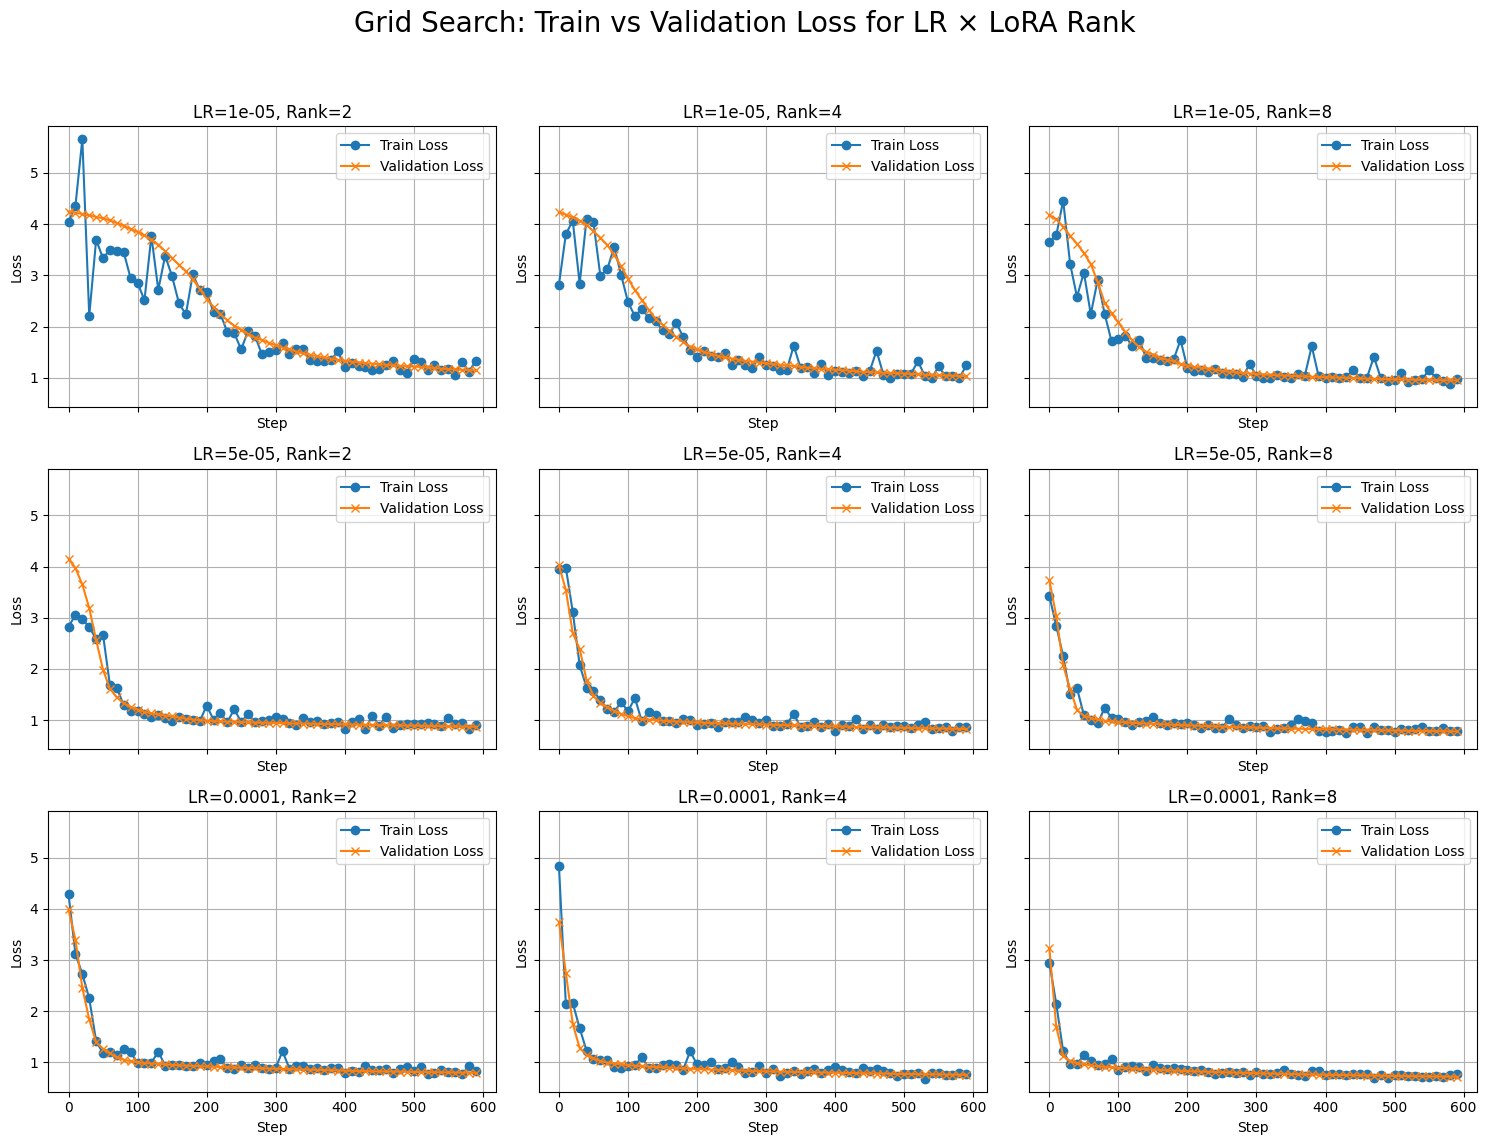

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Define the search space again
learning_rates = [1e-5, 5e-5, 1e-4]
lora_ranks = [2, 4, 8]


base_path = "results/3b"
results = []

for lr in learning_rates:
    for rank in lora_ranks:
        prefix = f"{base_path}/lr{lr:.0e}_rank{rank}"
        train_path = f"{prefix}_train_losses.npy"
        val_path = f"{prefix}_val_losses.npy"

        if os.path.exists(train_path) and os.path.exists(val_path):
            train_losses = np.load(train_path).tolist()
            val_losses = np.load(val_path).tolist()
            results.append({
                "lr": lr,
                "rank": rank,
                "train_losses": train_losses,
                "val_losses": val_losses
            })
        else:
            print(f"Missing files for lr={lr:.0e}, rank={rank}")

# Plot results loaded
if results:
    fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)

    for i, result in enumerate(results):
        row = i // 3
        col = i % 3
        ax = axes[row][col]

        steps = [10 * j for j in range(len(result["train_losses"]))]
        ax.plot(steps, result["train_losses"], label='Train Loss', marker='o')
        ax.plot(steps, result["val_losses"], label='Validation Loss', marker='x')
        ax.set_title(f"LR={result['lr']}, Rank={result['rank']}")
        ax.set_xlabel("Step")
        ax.set_ylabel("Loss")
        ax.grid(True)
        ax.legend()

    fig.suptitle("Grid Search: Train vs Validation Loss for LR × LoRA Rank", fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No results loaded.")


In [35]:
# Load the models back for evaluation

import torch
import torch.nn.functional as F
from qwen import load_qwen
from lora_skeleton import LoRALinear
from preprocessor import decode_prediction_to_array, rescale
from lora_implemented import generate_predictions
import h5py

# Parameters
learning_rates = [1e-5, 5e-5, 1e-4]
lora_ranks = [2, 4, 8]
alpha = 0.36
with h5py.File("../data/lotka_volterra_data.h5", "r") as f:
    trajectories = f["trajectories"][:]

results_mae_1 = []

for lr in learning_rates:
    for rank in lora_ranks:
        print(f"\n=== Inference for lr={lr:.0e}, rank={rank} ===")

        # Load model
        model, tokenizer = load_qwen()
        for layer in model.model.layers:
            layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=rank)
            layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=rank)

        # Load LoRA weights
        filename_prefix = f"results/3b/lr{lr:.0e}_rank{rank}"
        lora_weights = torch.load(f"{filename_prefix}_lora_weights.pth", map_location=device)
        model.load_state_dict(lora_weights, strict=False)

        model.to(device)
        model.eval()

        # Store Predictions & Ground Truths
        all_predictions = []
        all_gt = []     
        
        
        for i, system_id in enumerate(val_idx_subset):
            prompt_string = val_tune[i]
            traj_gt = trajectories[system_id]

            try:
                pred_tokens = generate_predictions(
                    prompt_string,
                    tokenizer=tokenizer,
                    model=model,
                    device=device,
                    max_new_tokens=400,
                    num_samples=1,
                    do_sample=False
                )[0]

                decoded_pred = decode_prediction_to_array(pred_tokens)
                rescaled_pred = rescale(decoded_pred, alpha=alpha)

                all_predictions.append(rescaled_pred)
                all_gt.append(traj_gt)

            except Exception as e:
                print(f"[{i}] System {system_id} failed: {e}")
                all_predictions.append(None)
                all_gt.append(traj_gt)



        # MAE
        mae_list = []

        for pred, gt in zip(all_predictions, all_gt):
            if pred is None:
                continue

            gt_shifted = gt[70:]
            pred_tensor = torch.tensor(pred)

            n = min(30, pred_tensor.shape[0], gt_shifted.shape[0])
            pred_tensor = pred_tensor[:n]
            gt_tensor = torch.tensor(gt_shifted[:n])

            mae = F.l1_loss(pred_tensor, gt_tensor)
            mae_list.append(mae.item())

        mean_mae = sum(mae_list) / len(mae_list)
        print(f"MAE for lr={lr:.0e}, rank={rank}: {mean_mae:.4f}")

        results_mae_1.append({
            "lr": lr,
            "rank": rank,
            "mae": mean_mae,
        })



=== Inference for lr=1e-05, rank=2 ===


/tmp/ipykernel_2419916/1000041196.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lora_weights = torch.load(f"{filename_prefix}_lora_weights.pth", map_location=device)


MAE for lr=1e-05, rank=2: 0.6703

=== Inference for lr=1e-05, rank=4 ===
MAE for lr=1e-05, rank=4: 0.8995

=== Inference for lr=1e-05, rank=8 ===
MAE for lr=1e-05, rank=8: 0.5500

=== Inference for lr=5e-05, rank=2 ===
MAE for lr=5e-05, rank=2: 2.6359

=== Inference for lr=5e-05, rank=4 ===
MAE for lr=5e-05, rank=4: 1.0487

=== Inference for lr=5e-05, rank=8 ===
MAE for lr=5e-05, rank=8: 0.3639

=== Inference for lr=1e-04, rank=2 ===
MAE for lr=1e-04, rank=2: 0.4914

=== Inference for lr=1e-04, rank=4 ===
MAE for lr=1e-04, rank=4: 0.3141

=== Inference for lr=1e-04, rank=8 ===
MAE for lr=1e-04, rank=8: 0.2623


# # 3(b) Task 2: Additional experiments to explore the effect of the context length in (128, 512, 768)

In [5]:
# Use small size of dataset to tune hyperparameters (30%)

train_tune = train_set[0:240]
val_tune = val_prompt[0:60]
val_idx_subset = val_idx[:60]

*Note that although a context length of 512 is used here for clarity, this configuration is already included in one of the grid search runs since 512 is the default parameter. Therefore, the FLOPS for this particular experiment are not counted separately.

In [6]:
import numpy as np
import torch

# Define search space
ctx_length = [128, 512, 768]


# Store results
results = []

# Grid search
for ctx in ctx_length:

    print(f"\n--- Training with ctx_length={ctx}")
        
    # Prepare model and optimizer
    model, tokenizer, optimizer = prepare_model(lora_rank=8, learning_rate=1e-4)
    train_ids, val_ids = tokenise_data(train_tune, val_tune, tokenizer, max_ctx_length=ctx)
    train_loader = prepare_data_loader(train_ids, batch_size=4)

    # Train
    train_losses, val_losses, last_step_train_loss = train(
            model, optimizer, train_loader, val_ids,
            train_steps=600, val_every=10
        )
        

    # Save training info in results
    results.append({
            "ctx": ctx,
            "train_losses": train_losses.copy(),
            "val_losses": val_losses.copy(),
            "final_train_loss": train_losses[-1],
            "final_val_loss": val_losses[-1],
            "last_step_train_loss": last_step_train_loss})

    # Save to files
    filename_prefix = f"results/3b/ctx{ctx}"
    np.save(f"{filename_prefix}_train_losses.npy", np.array(train_losses))
    np.save(f"{filename_prefix}_val_losses.npy", np.array(val_losses))
        
    # Save only lora weights

    lora_weights = {
        name: param.detach().cpu().clone()
        for name, param in model.named_parameters()
        if param.requires_grad
        }
    torch.save(lora_weights, f"{filename_prefix}_lora_weights.pth")



--- Training with ctx_length=128


Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.
Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Training @ step 0:  52%|█████▏    | 599/1153 [06:05<05:37,  1.64it/s, loss=1.09] 



--- Training with ctx_length=512


Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Training @ step 302:  98%|█████████▊| 297/302 [04:07<00:04,  1.20it/s, loss=0.633]



--- Training with ctx_length=768


Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Training @ step 480:  50%|████▉     | 119/240 [02:22<02:24,  1.20s/it, loss=0.827]


In [7]:
import pandas as pd

summary2 = pd.DataFrame([
    {
        "context length": r["ctx"],
        "final_avg_train_loss": r["final_train_loss"],       
        "last_batch_train_loss": r["last_step_train_loss"],  
        "final_val_loss": r["final_val_loss"]
    }
    for r in results
])


summary2 = summary2.sort_values("final_val_loss").reset_index(drop=True)

summary2


,context length,final_avg_train_loss,last_batch_train_loss,final_val_loss
0,768,0.638658,0.826706,0.482370
1,512,0.731722,0.632588,0.715776
2,128,0.952362,1.086179,0.900347


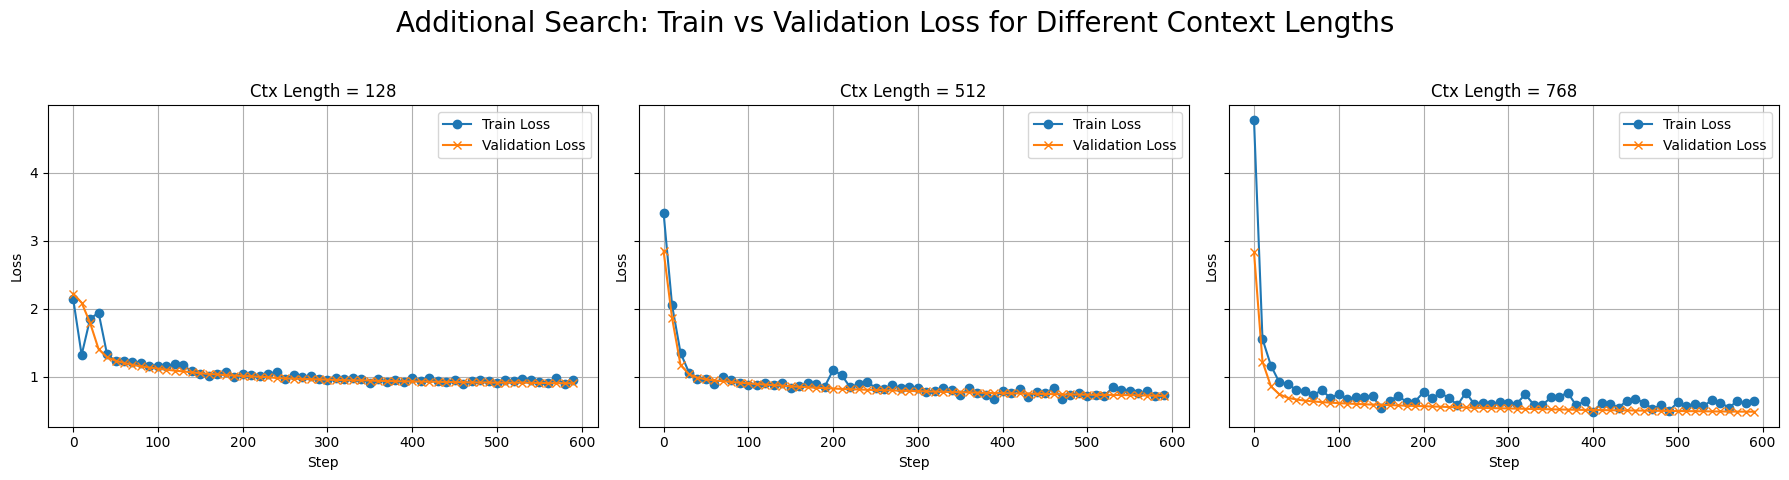

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt


ctx_lengths = [128, 512, 768]

base_path = "results/3b"
results = []

for ctx in ctx_lengths:
    prefix = f"{base_path}/ctx{ctx}"
    train_path = f"{prefix}_train_losses.npy"
    val_path = f"{prefix}_val_losses.npy"

    if os.path.exists(train_path) and os.path.exists(val_path):
        train_losses = np.load(train_path).tolist()
        val_losses = np.load(val_path).tolist()
        results.append({
            "ctx": ctx,
            "train_losses": train_losses,
            "val_losses": val_losses
        })
    else:
        print(f"Missing files for ctx_length={ctx}")

if results:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

    for i, result in enumerate(results):
        ax = axes[i]
        steps = [10 * j for j in range(len(result["train_losses"]))]
        ax.plot(steps, result["train_losses"], label='Train Loss', marker='o')
        ax.plot(steps, result["val_losses"], label='Validation Loss', marker='x')
        ax.set_title(f"Ctx Length = {result['ctx']}")
        ax.set_xlabel("Step")
        ax.set_ylabel("Loss")
        ax.grid(True)
        ax.legend()

    fig.suptitle("Additional Search: Train vs Validation Loss for Different Context Lengths", fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No results loaded.")


In [10]:
import os
import torch
import torch.nn.functional as F
import h5py
import numpy as np
from qwen import load_qwen
from lora_skeleton import LoRALinear
from preprocessor import decode_prediction_to_array, rescale, load_and_preprocess
from lora_implemented import generate_predictions


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

(train_set, _), (val_set, val_idx) = load_and_preprocess(
         "../data/lotka_volterra_data.h5", alpha=0.36, precision=3)
val_prompt = val_set[1]
train_tune = train_set[0:240]
val_tune = val_prompt[0:60]
val_idx_subset = val_idx[:60]


with h5py.File("../data/lotka_volterra_data.h5", "r") as f:
    trajectories = f["trajectories"][:]

alpha = 0.36
ctx_lengths = [128, 512, 768]
results_mae_ctx = []

for ctx in ctx_lengths:
    print(f"\n=== Inference for ctx_length={ctx} ===")


    model, tokenizer = load_qwen()
    for layer in model.model.layers:
        layer.self_attn.q_proj = LoRALinear(layer.self_attn.q_proj, r=8)
        layer.self_attn.v_proj = LoRALinear(layer.self_attn.v_proj, r=8)
    

    filename_prefix = f"results/3b/ctx{ctx}"
    lora_weights_path = f"{filename_prefix}_lora_weights.pth"
    if not os.path.exists(lora_weights_path):
        print(f"Missing weights file for ctx_length={ctx}")
        continue
    lora_weights = torch.load(lora_weights_path, map_location=device)
    model.load_state_dict(lora_weights, strict=False)

    model.to(device)
    model.eval()

    # Inference
    all_predictions_ctx = []
    all_gt_ctx = []
    
    for i, system_id in enumerate(val_idx_subset):
        prompt_string = val_tune[i]
        traj_gt = trajectories[system_id]
        
        try:
            pred_tokens = generate_predictions(
                prompt_string,
                tokenizer=tokenizer,
                model=model,
                device=device,
                max_new_tokens=420,
                num_samples=1,
                do_sample=False
            )[0]

            decoded_pred = decode_prediction_to_array(pred_tokens)
            rescaled_pred = rescale(decoded_pred, alpha=alpha)

            all_predictions_ctx.append(rescaled_pred)
            all_gt_ctx.append(traj_gt)
        except Exception as e:
            print(f"[{i}] System {system_id} failed: {e}")
            all_predictions_ctx.append(None)
            all_gt_ctx.append(traj_gt)
    
    
    # MAE
    mae_list = []
    for pred, gt in zip(all_predictions_ctx, all_gt_ctx):
        if pred is None:
            continue
        pred_tensor = torch.tensor(pred)
        if pred_tensor.shape[0] == 0:
            continue

        gt_shifted = gt[70:]
        n = min(30, pred_tensor.shape[0], gt_shifted.shape[0])
        pred_tensor = pred_tensor[:n]
        gt_tensor = torch.tensor(gt_shifted[:n])
        mae = F.l1_loss(pred_tensor, gt_tensor)
        mae_list.append(mae.item())

    mean_mae = sum(mae_list) / len(mae_list) if mae_list else float('nan')
    print(f"MAE for ctx_length={ctx}: {mean_mae:.4f}")
    results_mae_ctx.append({
        "ctx": ctx,
        "mae": mean_mae
    })


=== Inference for ctx_length=128 ===


/tmp/ipykernel_2112802/565059696.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lora_weights = torch.load(lora_weights_path, map_location=device)


MAE for ctx_length=128: 0.8556

=== Inference for ctx_length=512 ===
MAE for ctx_length=512: 0.2375

=== Inference for ctx_length=768 ===
MAE for ctx_length=768: 0.2175


# 3(c) Based on trends observed in the previous experiments, select a set of hyperparameters to use for the final model. Evaluate on the validation set.

In [4]:
# 3(c) Train on the whole training set based on the optimal hyperparameters. 
import numpy as np

from lora_implemented import train
from lora_implemented import tokenise_data, prepare_data_loader, prepare_model

# Prepare full dataset
train_full = train_set
val_full = val_prompt

model, tokenizer, optimizer = prepare_model(lora_rank=8, learning_rate=1e-4)

# Tokenise
train_ids_full, val_ids_full = tokenise_data(train_full, val_full, tokenizer, max_ctx_length=768)


# Loader
train_loader_full = prepare_data_loader(train_ids_full, batch_size=4)

# Train
train_losses_3c, val_losses_3c, _ = train(model, optimizer, train_loader_full, val_ids_full, train_steps=3000, val_every=100)


# Save training data
filename_prefix = "results/3c/experiment"


np.save(f"{filename_prefix}_train_losses.npy", np.array(train_losses_3c))
np.save(f"{filename_prefix}_val_losses.npy", np.array(val_losses_3c))

# LoRA weights
lora_weights = {
    name: param.detach().cpu().clone()
    for name, param in model.named_parameters()
    if param.requires_grad
}
torch.save(lora_weights, f"{filename_prefix}_lora_weights.pth")


Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
Training @ step 2400:  75%|███████▍  | 599/800 [07:17<02:26,  1.37it/s, loss=0.545]  


In [14]:
import numpy as np

filename_prefix = "results/3c/experiment"

train_losses_3c = np.load(f"{filename_prefix}_train_losses.npy")
val_losses_3c = np.load(f"{filename_prefix}_val_losses.npy")

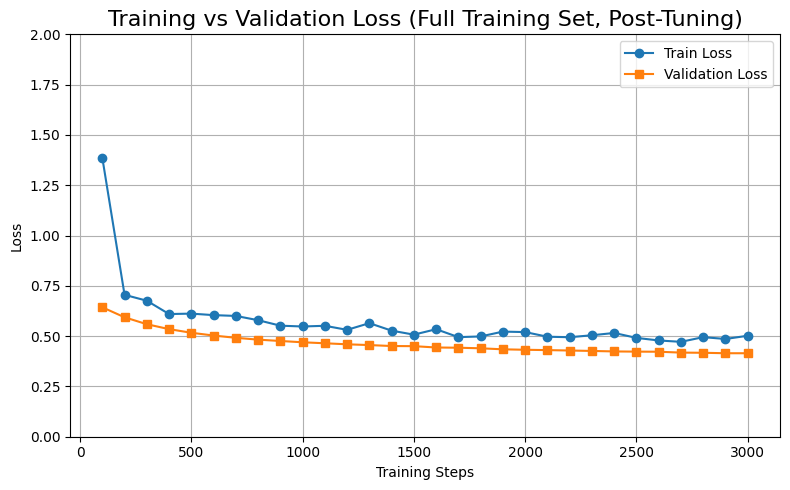

In [7]:
# 3(c): Visualisation
import matplotlib.pyplot as plt

val_every = 100 
steps = list(range(val_every, val_every * len(val_losses_3c) + 1, val_every))

plt.figure(figsize=(8, 5))
plt.plot(steps, train_losses_3c, label="Train Loss", marker='o')
plt.plot(steps, val_losses_3c, label="Validation Loss", marker='s')
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Full Training Set, Post-Tuning)", fontsize = 16)
plt.legend()
plt.ylim(0,2)
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# ====== Predict on entire validation set ======
import h5py
from lora_implemented import generate_predictions
from preprocessor import decode_prediction_to_array, rescale, load_and_preprocess
with h5py.File("../data/lotka_volterra_data.h5", "r") as f:
    trajectories = f["trajectories"][:]

all_predictions_3c = []  # list of np.ndarray, each of shape (≤30, 2)
all_gt_3c = []           # list of np.ndarray, each of shape (100, 2)

for i, system_id in enumerate(val_idx):
    prompt_string = val_set[1][i]  # 70-point LLMTIME string
    traj_gt = trajectories[system_id]

    try:
        # Predict
        pred_tokens = generate_predictions(
            prompt_string,
            tokenizer=tokenizer,
            model=model,
            device=device,
            max_new_tokens=420,
            num_samples=1,
            do_sample=False
        )[0]

        # Decode and rescale
        decoded_pred = decode_prediction_to_array(pred_tokens)
        rescaled_pred = rescale(decoded_pred, alpha=0.36)

        all_predictions_3c.append(rescaled_pred)
        all_gt_3c.append(traj_gt)

    except Exception as e:
        print(f"[{i}] System {system_id} failed: {e}")
        all_predictions_3c.append(None)
        all_gt_3c.append(traj_gt)


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [24]:
import torch.nn.functional as F
import math

mae_list_3c = []
system_ids_3c = []
squared_error_list_3c = []

for i, (pred, gt) in enumerate(zip(all_predictions_3c, all_gt_3c)):
    if pred is None:
        continue

    gt_shifted = gt[70:]
    pred_tensor = torch.tensor(pred)

    n = min(30, pred_tensor.shape[0], gt_shifted.shape[0])
    pred_tensor = pred_tensor[:n]
    gt_tensor = torch.tensor(gt_shifted[:n])

    # MAE
    mae = F.l1_loss(pred_tensor, gt_tensor)
    mae_list_3c.append(mae.item())
    system_ids_3c.append(i)
    
    # Squared Error (for RMSE)
    squared_error = F.mse_loss(pred_tensor, gt_tensor)
    squared_error_list_3c.append(squared_error.item())

mean_mae = sum(mae_list_3c) / len(mae_list_3c)
rmse = math.sqrt(sum(squared_error_list_3c) / len(squared_error_list_3c))

# Standard deviation
std_mae = np.std(mae_list_3c)
std_rmse = np.std(squared_error_list_3c)

print(f"MAE  - Mean: {mean_mae:.4f} | Std: {std_mae:.4f}")
print(f"RMSE - Mean: {rmse:.4f} | Std: {std_rmse:.4f}")

MAE  - Mean: 0.1669 | Std: 0.1833
RMSE - Mean: 0.3873 | Std: 0.4136


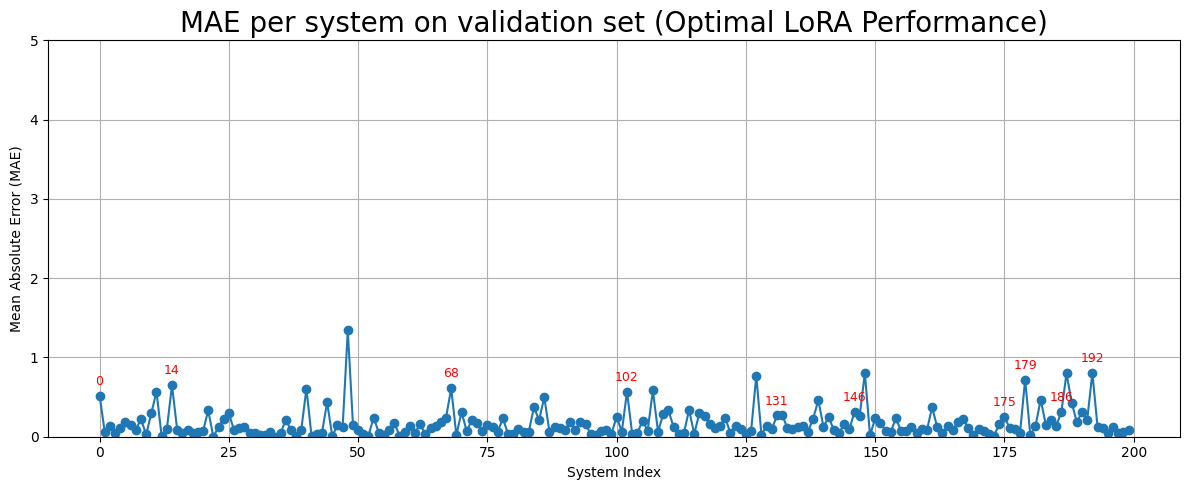

In [16]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# MAE Plot for Finetuned prediction

plt.figure(figsize=(12, 5))
plt.plot(system_ids_3c, mae_list_3c, marker='o')
plt.title("MAE per system on validation set (Optimal LoRA Performance)", fontsize = 20)
plt.xlabel("System Index")
plt.ylabel("Mean Absolute Error (MAE)")
plt.grid(True)
plt.ylim(0, 5)

for sid, mae in zip(system_ids_3c, mae_list_3c):
    if sid in [0, 14, 68, 102, 131, 146, 175, 179, 186, 192]:
        plt.text(sid, mae + 0.1, f"{sid}", ha='center', va='bottom', fontsize=9, color='red')


plt.tight_layout()
plt.show()


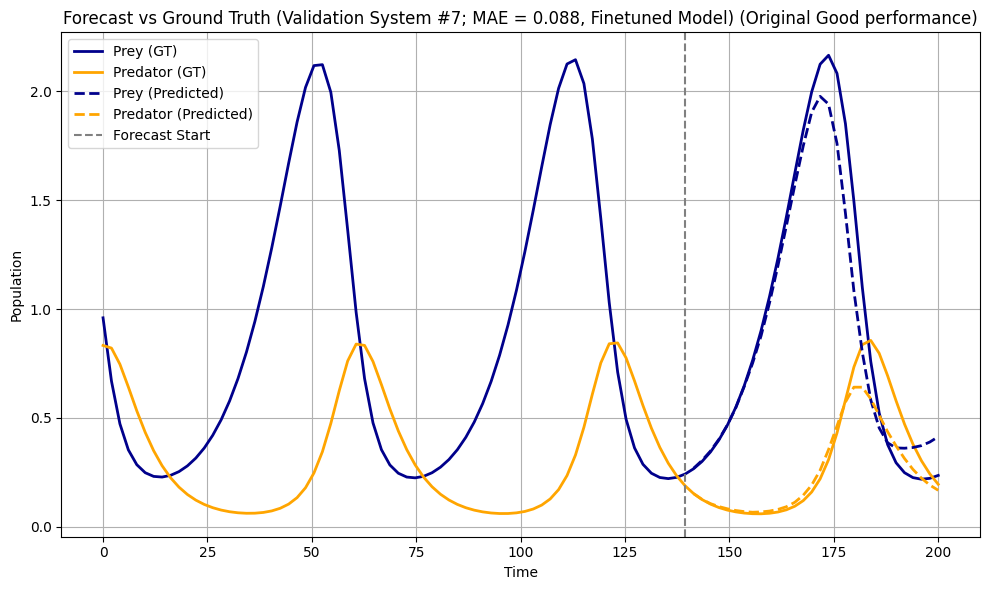

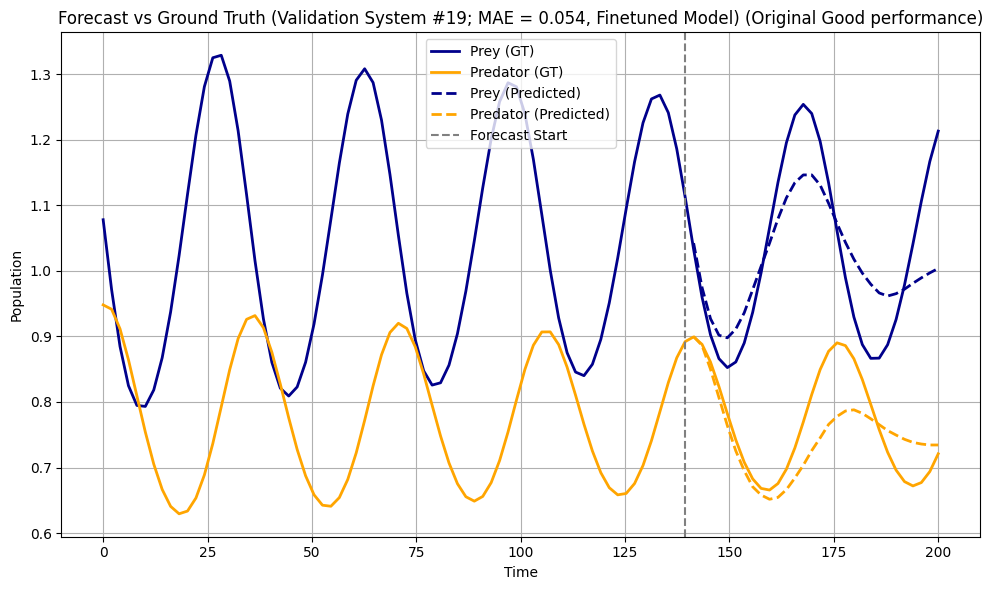

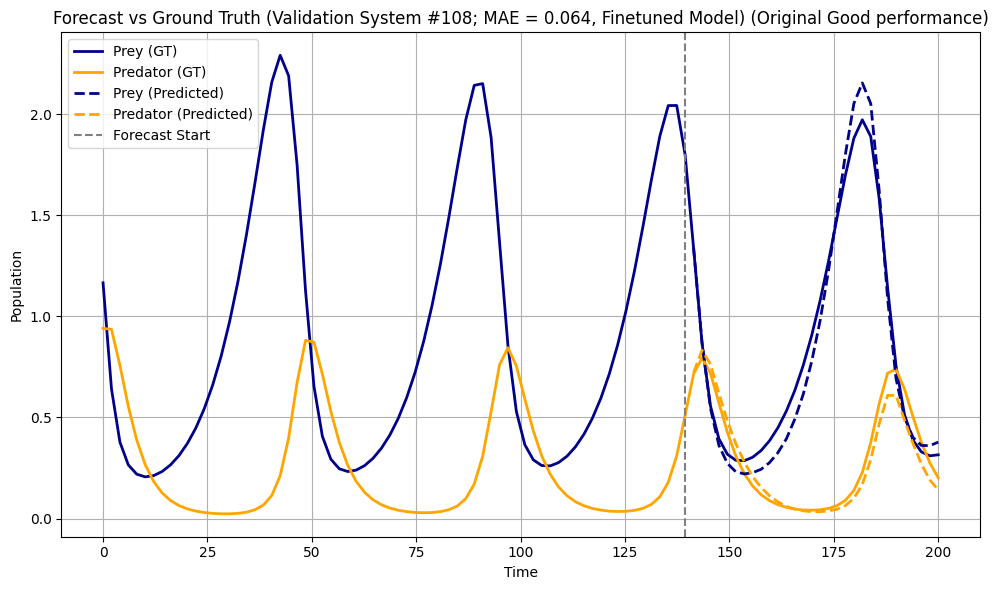

In [11]:
chosen_indices = [7, 19, 108]
with h5py.File("../data/lotka_volterra_data.h5", "r") as f:
    trajectories = f["trajectories"][:]
    time_points = f["time"][:]

for i in chosen_indices:
    pred = all_predictions_3c[i]
    gt = all_gt_3c[i]

    if pred is None:
        print(f"System {i} skipped (no prediction)")
        continue


    max_pred_steps = 30
    forecast_start = 70
    pred_len = min(pred.shape[0], max_pred_steps)

    times_pred = time_points[forecast_start:forecast_start + pred_len]
    pred_trimmed = pred[:pred_len]
    gt_trimmed = gt[:100]

    # Get system id
    idx_in_mae_list = system_ids_3c.index(i)
    mae = mae_list_3c[idx_in_mae_list]

    # Plot
    plt.figure(figsize=(10, 6))

    # Ground truth
    plt.plot(time_points, gt[:, 0], label="Prey (GT)", color="darkblue", linewidth=2)
    plt.plot(time_points, gt[:, 1], label="Predator (GT)", color="orange", linewidth=2)

    # Prediction
    plt.plot(times_pred, pred_trimmed[:, 0], "--", label="Prey (Predicted)", color="darkblue", linewidth=2)
    plt.plot(times_pred, pred_trimmed[:, 1], "--", label="Predator (Predicted)", color="orange", linewidth=2)
    plt.axvline(time_points[forecast_start - 1], color="gray", linestyle="--", label="Forecast Start")

    
    plt.xlabel("Time")
    plt.ylabel("Population")
    plt.title(f"Forecast vs Ground Truth (Validation System #{i}; MAE = {mae:.3f}, Finetuned Model) (Original Good performance)" )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


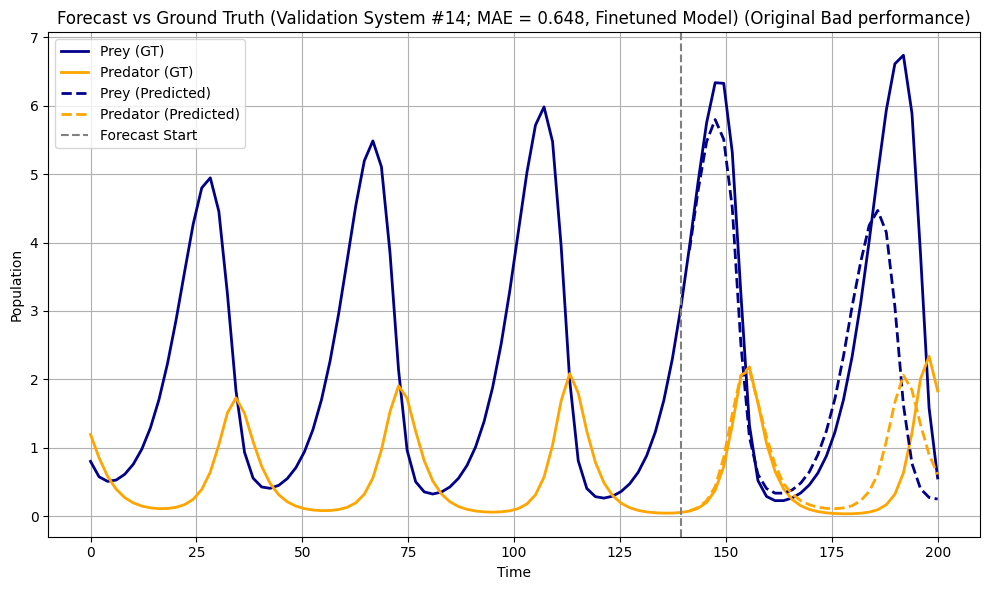

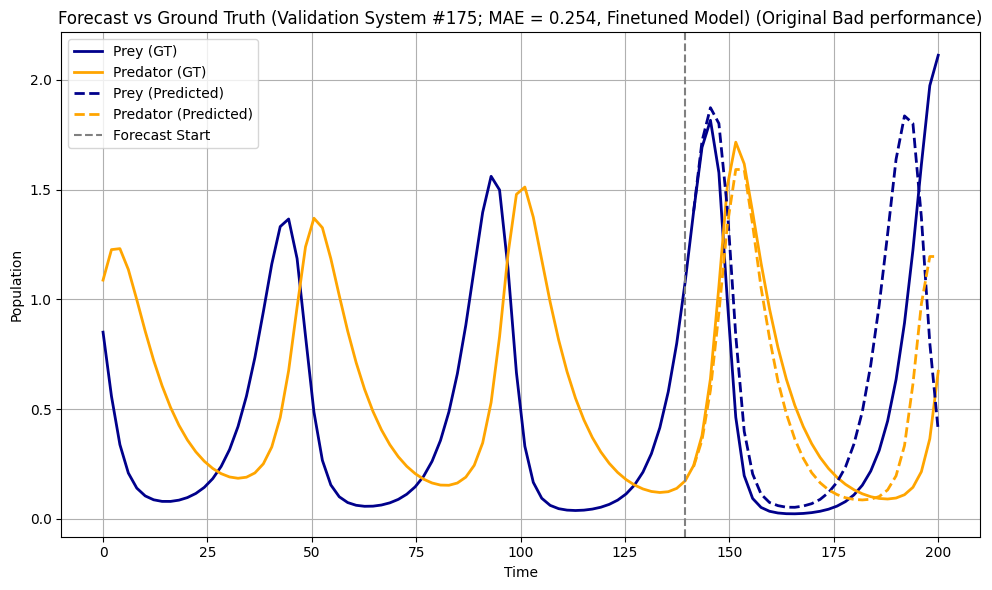

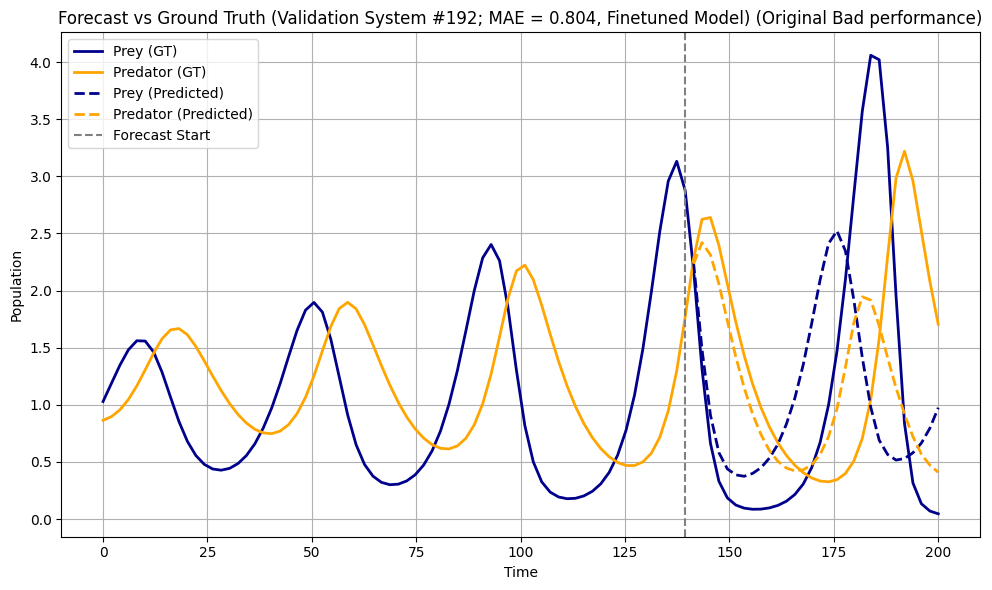

In [12]:
chosen_indices = [14, 175, 192]

for i in chosen_indices:
    pred = all_predictions_3c[i]
    gt = all_gt_3c[i]

    if pred is None:
        print(f"System {i} skipped (no prediction)")
        continue


    max_pred_steps = 30
    forecast_start = 70
    pred_len = min(pred.shape[0], max_pred_steps)

    times_pred = time_points[forecast_start:forecast_start + pred_len]
    pred_trimmed = pred[:pred_len]
    gt_trimmed = gt[:100]

    # Get system id
    idx_in_mae_list = system_ids_3c.index(i)
    mae = mae_list_3c[idx_in_mae_list]

    # Plot
    plt.figure(figsize=(10, 6))

    # Ground truth
    plt.plot(time_points, gt[:, 0], label="Prey (GT)", color="darkblue", linewidth=2)
    plt.plot(time_points, gt[:, 1], label="Predator (GT)", color="orange", linewidth=2)

    # Prediction
    plt.plot(times_pred, pred_trimmed[:, 0], "--", label="Prey (Predicted)", color="darkblue", linewidth=2)
    plt.plot(times_pred, pred_trimmed[:, 1], "--", label="Predator (Predicted)", color="orange", linewidth=2)
    plt.axvline(time_points[forecast_start - 1], color="gray", linestyle="--", label="Forecast Start")

    
    plt.xlabel("Time")
    plt.ylabel("Population")
    plt.title(f"Forecast vs Ground Truth (Validation System #{i}; MAE = {mae:.3f}, Finetuned Model) (Original Bad performance)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


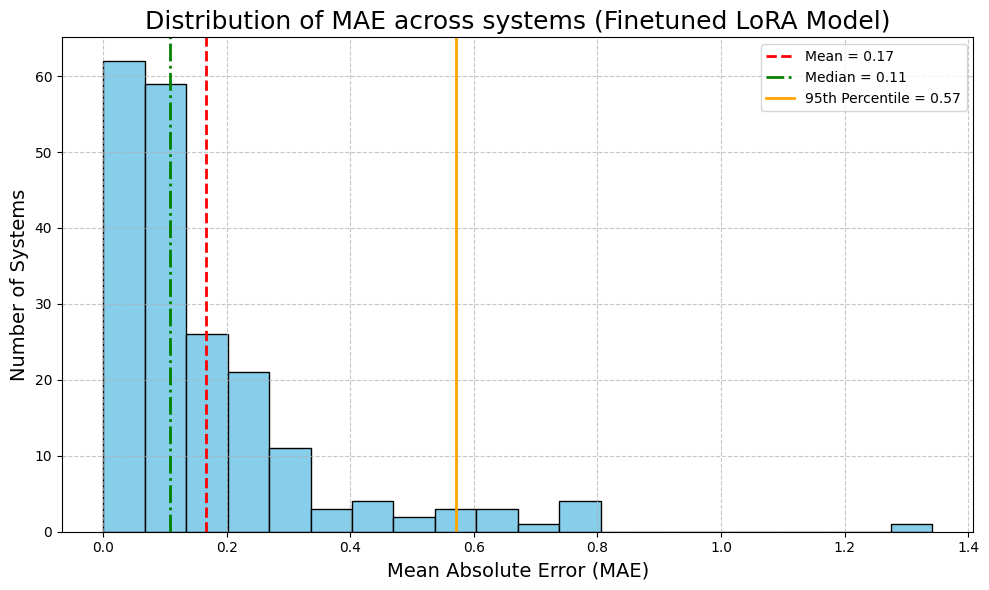

In [20]:
# Histogram of MAE values

mean_mae = np.mean(mae_list_3c)
median_mae = np.median(mae_list_3c)
percentile_95 = np.percentile(mae_list_3c, 95)

plt.figure(figsize=(10, 6))
plt.hist(mae_list_3c, bins=20, edgecolor='black', color='skyblue')
plt.title("Distribution of MAE across systems (Finetuned LoRA Model)", fontsize=18)
plt.axvline(mean_mae, color='red', linestyle='--', linewidth=2, label=f"Mean = {mean_mae:.2f}")
plt.axvline(median_mae, color='green', linestyle='-.', linewidth=2, label=f"Median = {median_mae:.2f}")
plt.axvline(percentile_95, color='orange', linestyle='-', linewidth=2, label=f"95th Percentile = {percentile_95:.2f}")

plt.xlabel("Mean Absolute Error (MAE)", fontsize=14)
plt.ylabel("Number of Systems", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()
plt.show()
